## 基于日常习惯的健康状态预测系统

### 导包

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

In [2]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

### 读取文件

In [3]:
df = pd.read_csv('data_set/hypothyroid.csv')
# df = pd.read_csv('health/health_lifestyle_classification.csv')
df.head()

,Age,sex,thyroxine,queryonthyroxine,onantithyroidmedication,sick,pregnant,thyroidsurgery,I131treatment,queryhypothyroid,...,TT4measured,T4,T4Umeasured,T4U,FTImeasured,FTI,TBGmeasured,TBG,referral source,binaryClass
0,12,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,?,SVHC,P
1,20,M,f,f,f,f,f,f,f,f,...,t,102.0,f,0.00,f,0.0,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175.0,f,0.00,f,0.0,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,?,SVI,P


### 查看前5行

In [4]:
df.head()

,Age,sex,thyroxine,queryonthyroxine,onantithyroidmedication,sick,pregnant,thyroidsurgery,I131treatment,queryhypothyroid,...,TT4measured,T4,T4Umeasured,T4U,FTImeasured,FTI,TBGmeasured,TBG,referral source,binaryClass
0,12,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,?,SVHC,P
1,20,M,f,f,f,f,f,f,f,f,...,t,102.0,f,0.00,f,0.0,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175.0,f,0.00,f,0.0,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,?,SVI,P


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3770 entries, 0 to 3769
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      3770 non-null   int64  
 1   sex                      3620 non-null   object 
 2   thyroxine                3770 non-null   object 
 3   queryonthyroxine         3770 non-null   object 
 4   onantithyroidmedication  3770 non-null   object 
 5   sick                     3770 non-null   object 
 6   pregnant                 3770 non-null   object 
 7   thyroidsurgery           3770 non-null   object 
 8   I131treatment            3770 non-null   object 
 9   queryhypothyroid         3770 non-null   object 
 10  queryhyperthyroid        3770 non-null   object 
 11  lithium                  3770 non-null   object 
 12  goitre                   3770 non-null   object 
 13  tumor                    3770 non-null   object 
 14  hypopituitary           

### 数据预处理

#### 查看缺失值

In [6]:
df.isnull().sum().sort_values(ascending=False).head(10)

sex                150
Age                  0
referral source      0
TBG                  0
TBGmeasured          0
FTI                  0
FTImeasured          0
T4U                  0
T4Umeasured          0
T4                   0
dtype: int64

#### 分离数值特征和分类特征

In [7]:
# 数值型特征
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# 类别型特征
cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [8]:
cat_cols

['sex',
 'thyroxine',
 'queryonthyroxine',
 'onantithyroidmedication',
 'sick',
 'pregnant',
 'thyroidsurgery',
 'I131treatment',
 'queryhypothyroid',
 'queryhyperthyroid',
 'lithium',
 'goitre',
 'tumor',
 'hypopituitary',
 'psych',
 'TSHmeasured',
 'T3measured',
 'TT4measured',
 'T4Umeasured',
 'FTImeasured',
 'TBGmeasured',
 'TBG',
 'referral source',
 'binaryClass']

#### 分析数值特征

##### 分布图

count    3770.000000
mean       51.724934
std        20.097915
min         1.000000
25%        36.000000
50%        54.000000
75%        67.000000
max       455.000000
Name: Age, dtype: float64


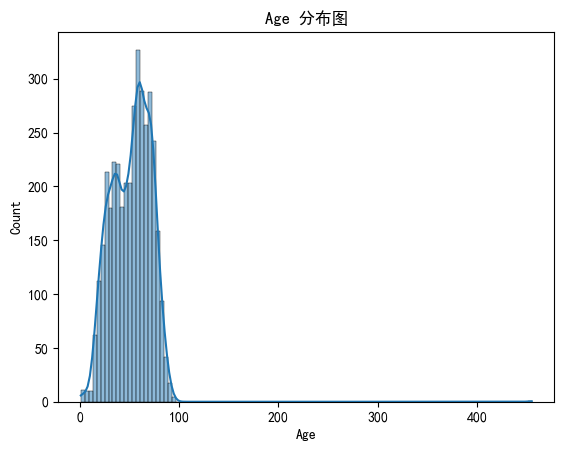

count    3770.000000
mean        4.591025
std        23.345886
min         0.000000
25%         0.200000
50%         1.200000
75%         2.475000
max       530.000000
Name: TSH, dtype: float64


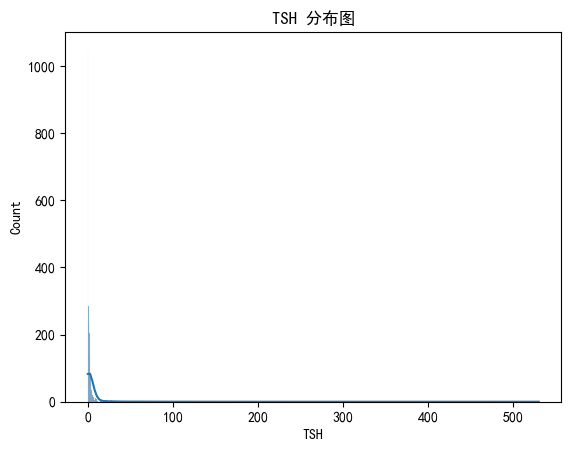

count    3770.000000
mean        1.603008
std         1.097207
min         0.000000
25%         0.900000
50%         1.800000
75%         2.200000
max        10.600000
Name: T3, dtype: float64


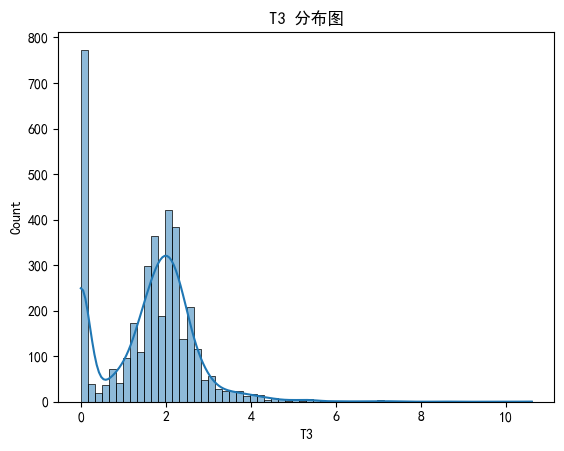

count    3770.000000
mean      101.678462
std        43.192637
min         0.000000
25%        84.000000
50%       102.000000
75%       123.000000
max       430.000000
Name: T4, dtype: float64


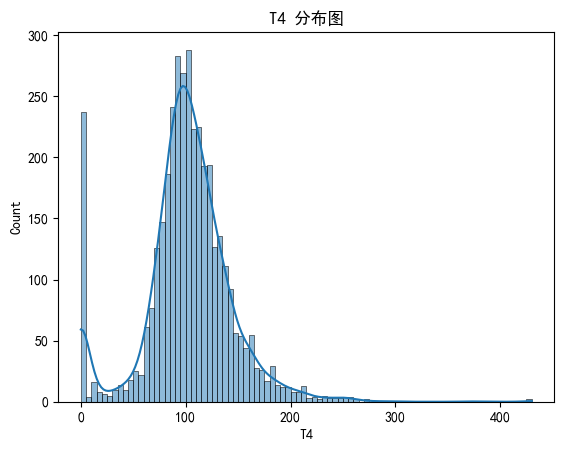

count    3770.000000
mean        0.892921
std         0.354295
min         0.000000
25%         0.840000
50%         0.950000
75%         1.070000
max         2.320000
Name: T4U, dtype: float64


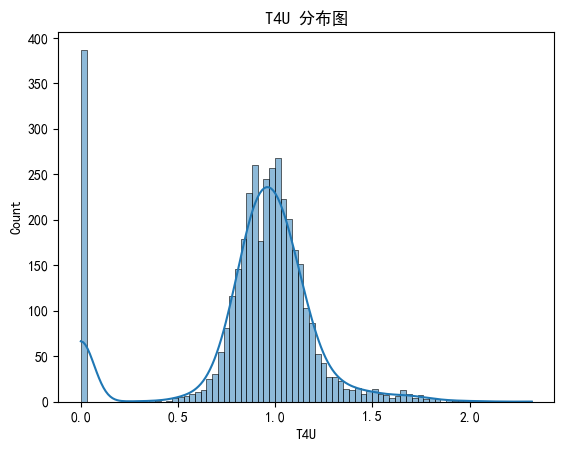

count    3770.000000
mean       99.176844
std        45.851205
min         0.000000
25%        86.250000
50%       104.000000
75%       121.000000
max       395.000000
Name: FTI, dtype: float64


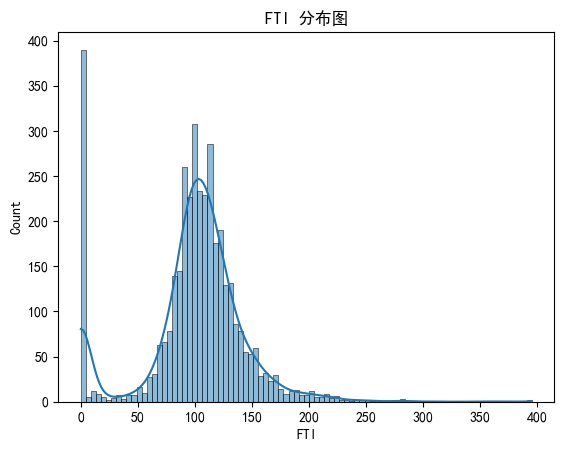

In [9]:
def summary_numeric(col):
    print(df[col].describe())
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} 分布图")
    plt.show()

for col in num_cols:
    summary_numeric(col)

##### 箱线图

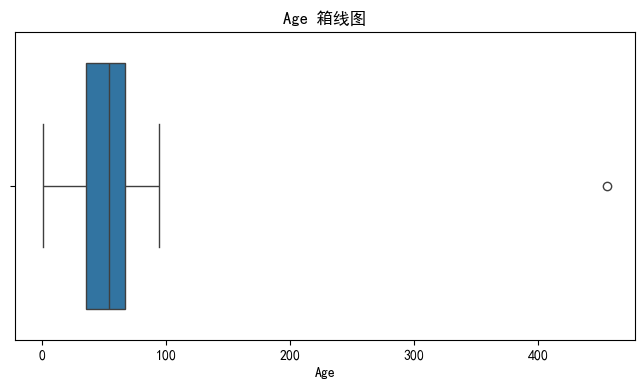

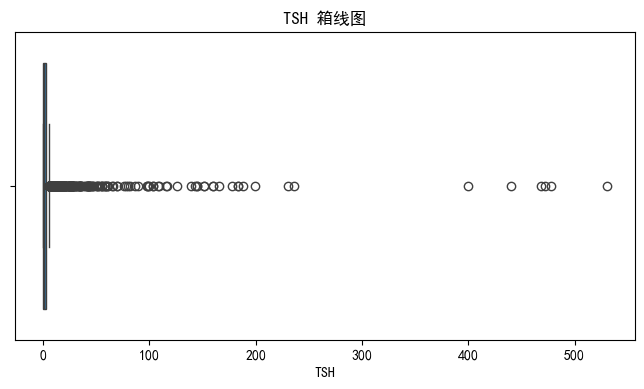

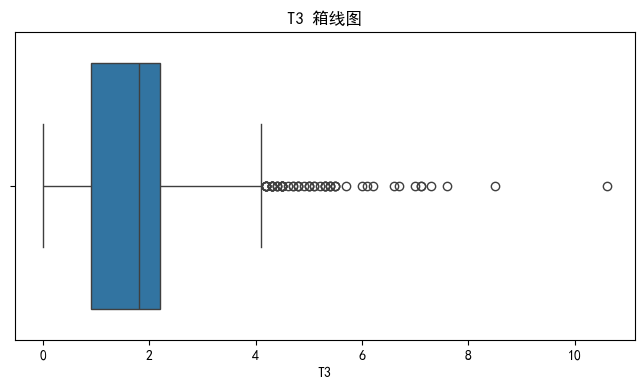

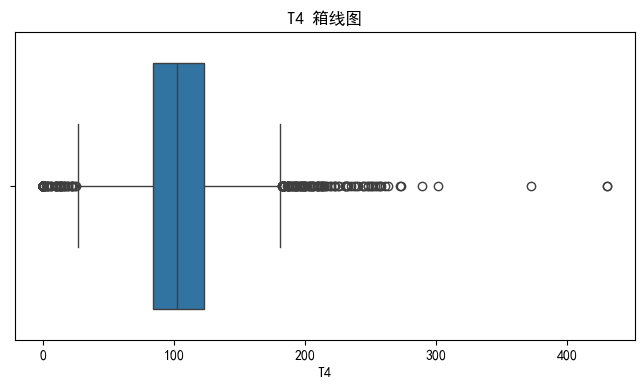

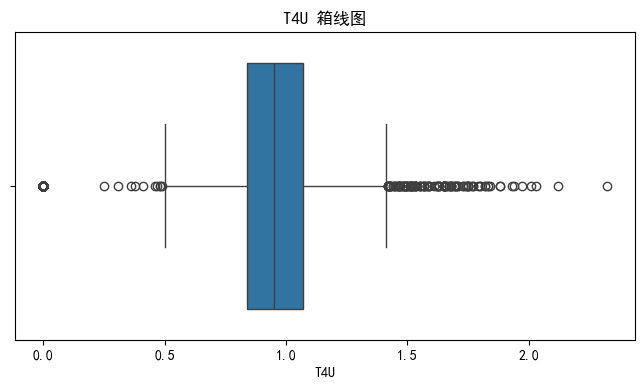

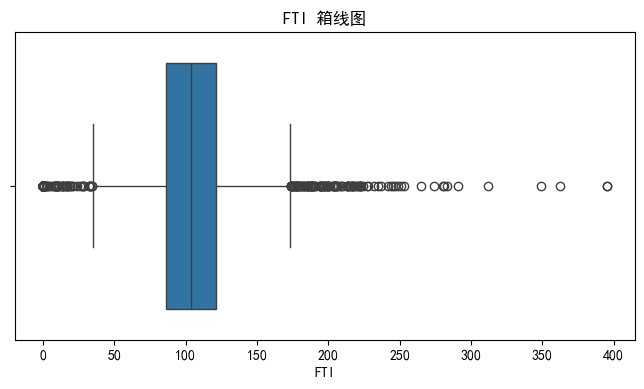

In [10]:
def boxplot_numeric(col):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} 箱线图")
    plt.show()

for col in num_cols:
    boxplot_numeric(col)


##### 删除低方差列

In [11]:
# 设定方差阈值
from sklearn.feature_selection import VarianceThreshold

var_thresh = VarianceThreshold(threshold=0.1)
var_thresh.fit(df[num_cols])
# 选择高方差特征
high_var_features = df[num_cols].columns[var_thresh.get_support()]
print('删除低方差列之前的列数',len(num_cols))
print('删除低方差列之后的列数',len(high_var_features))

删除低方差列之前的列数 6
删除低方差列之后的列数 6


In [12]:
num_cols

['Age', 'TSH', 'T3', 'T4', 'T4U', 'FTI']

In [13]:
high_var_features

Index(['Age', 'TSH', 'T3', 'T4', 'T4U', 'FTI'], dtype='object')

##### 处理离群值

In [14]:
def outlier_thresholds(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

def check_outliers(data, col):
    lower, upper = outlier_thresholds(data, col)
    return data[(data[col] < lower) | (data[col] > upper)]

for col in high_var_features:
    print(f"{col} 异常值数量:", len(check_outliers(df, col)))

Age 异常值数量: 1
TSH 异常值数量: 376
T3 异常值数量: 61
T4 异常值数量: 397
T4U 异常值数量: 521
FTI 异常值数量: 561


In [15]:
def replace_outliers_with_median(data, col):
    lower, upper = outlier_thresholds(data, col)
    median = data[col].median()
    data[col] = np.where((data[col] < lower) | (data[col] > upper), median, data[col])

for col in high_var_features:
    replace_outliers_with_median(df, col)

##### 填补空值

In [16]:
from sklearn.impute import KNNImputer

# 假设 high_var_features 是你要填充的特征列
imputer = KNNImputer(n_neighbors=5)  # 设置 KNN 的邻居数量

# 使用 KNN 填充缺失值
df[high_var_features] = imputer.fit_transform(df[high_var_features])

# 检查填充后的缺失值数量
df[high_var_features].isnull().sum().sort_values(ascending=False).head(10)

Age    0
TSH    0
T3     0
T4     0
T4U    0
FTI    0
dtype: int64

In [17]:
df.isnull().sum().sort_values(ascending=False).head(10)

sex                150
Age                  0
referral source      0
TBG                  0
TBGmeasured          0
FTI                  0
FTImeasured          0
T4U                  0
T4Umeasured          0
T4                   0
dtype: int64

##### 绘制初步处理后的分布图和箱线图

count    3770.000000
mean       51.618568
std        18.993858
min         1.000000
25%        36.000000
50%        54.000000
75%        67.000000
max        94.000000
Name: Age, dtype: float64


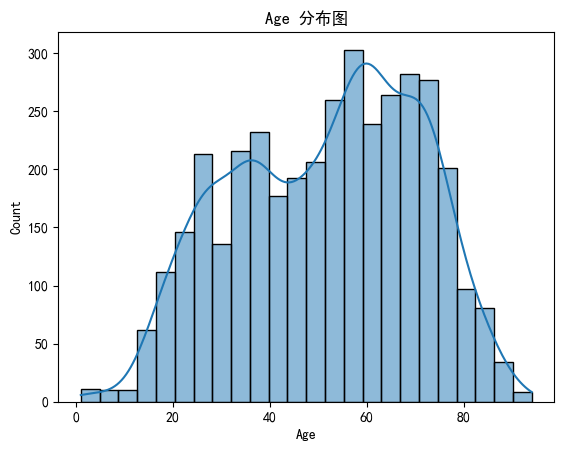

count    3770.000000
mean        1.278850
std         1.228763
min         0.000000
25%         0.200000
50%         1.200000
75%         1.900000
max         5.800000
Name: TSH, dtype: float64


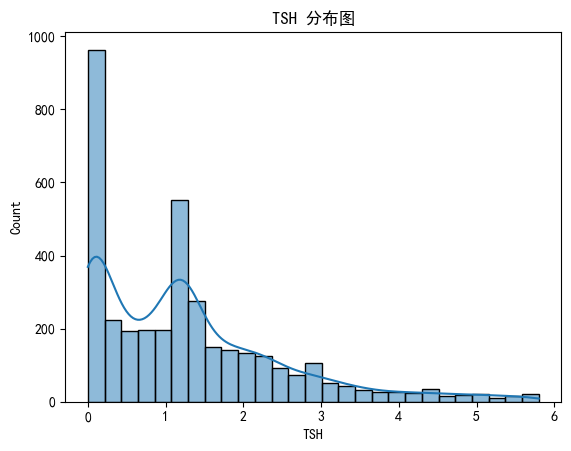

count    3770.000000
mean        1.547570
std         0.982642
min         0.000000
25%         0.900000
50%         1.800000
75%         2.200000
max         4.100000
Name: T3, dtype: float64


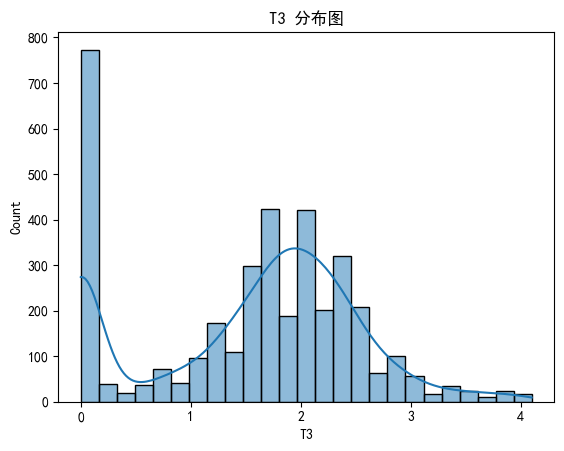

count    3770.000000
mean      105.150928
std        25.583585
min        27.000000
25%        90.000000
50%       102.000000
75%       120.000000
max       181.000000
Name: T4, dtype: float64


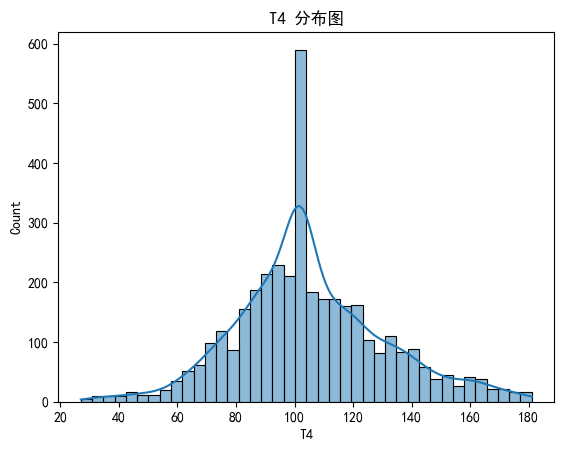

count    3770.000000
mean        0.969908
std         0.139244
min         0.500000
25%         0.890000
50%         0.950000
75%         1.050000
max         1.410000
Name: T4U, dtype: float64


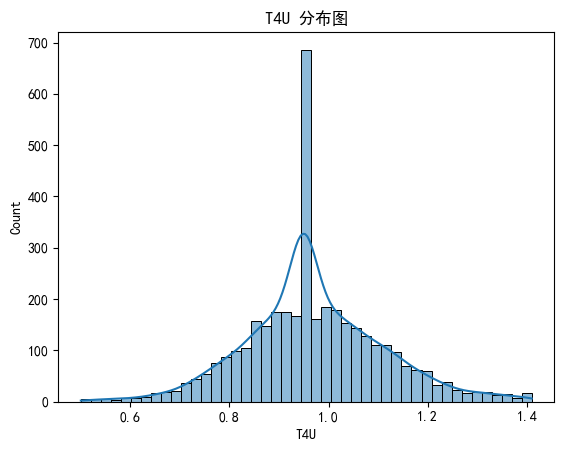

count    3770.000000
mean      107.313263
std        21.747722
min        35.000000
25%        95.000000
50%       104.000000
75%       118.000000
max       173.000000
Name: FTI, dtype: float64


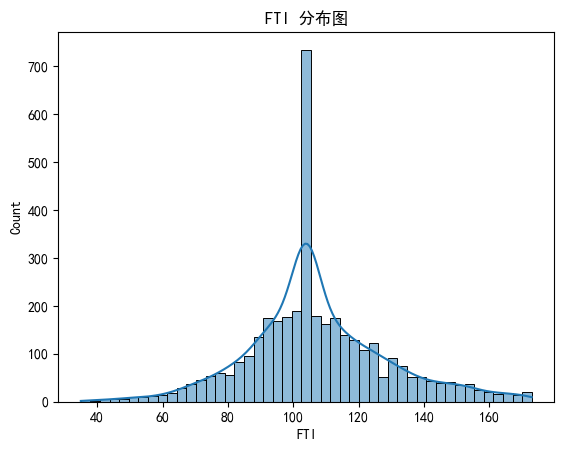

In [18]:
def summary_numeric(col):
    print(df[col].describe())
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} 分布图")
    plt.show()

for col in high_var_features:
    summary_numeric(col)

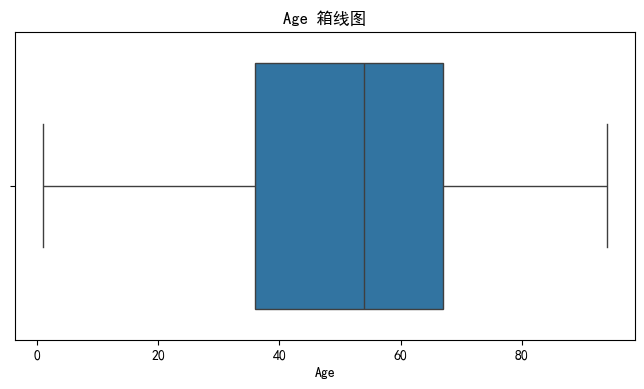

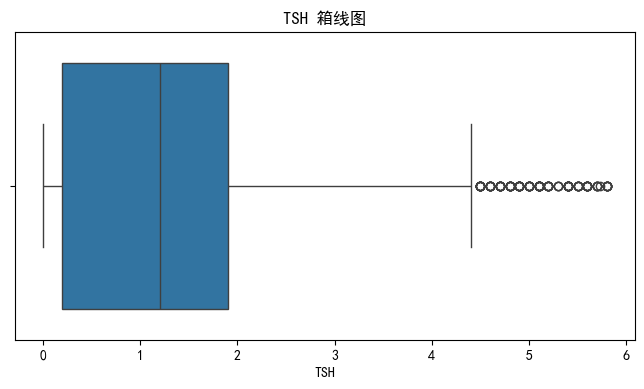

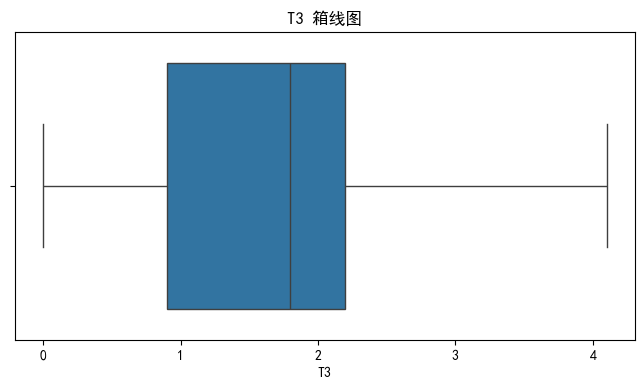

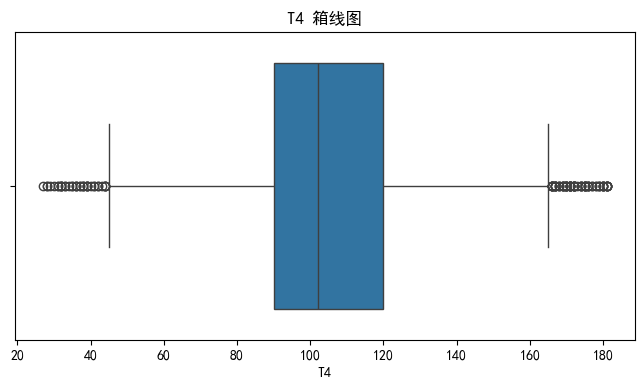

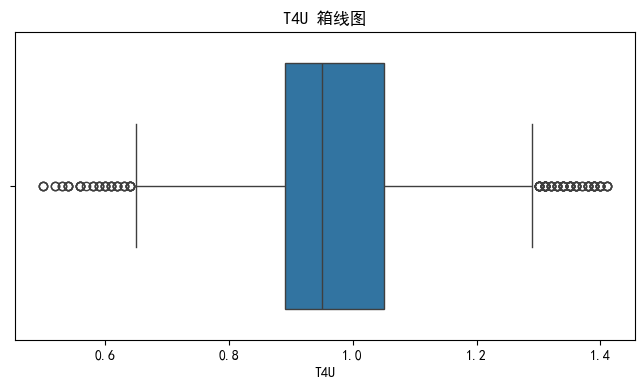

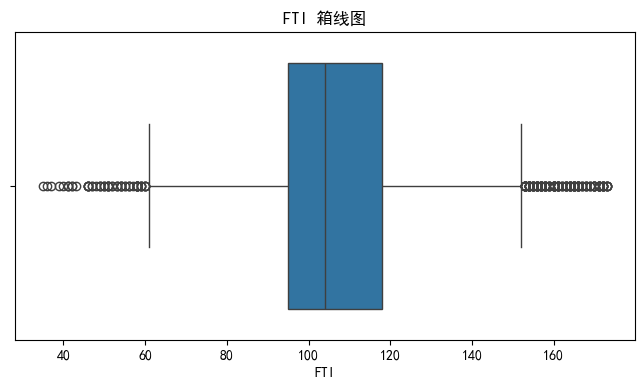

In [19]:
def boxplot_numeric(col):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} 箱线图")
    plt.show()

for col in high_var_features:
    boxplot_numeric(col)

#### 分析分类特征

##### 查看唯一值

In [20]:
df[cat_cols].nunique()

sex                        2
thyroxine                  2
queryonthyroxine           2
onantithyroidmedication    2
sick                       2
pregnant                   2
thyroidsurgery             2
I131treatment              2
queryhypothyroid           2
queryhyperthyroid          2
lithium                    2
goitre                     2
tumor                      2
hypopituitary              2
psych                      2
TSHmeasured                2
T3measured                 2
TT4measured                2
T4Umeasured                2
FTImeasured                2
TBGmeasured                1
TBG                        1
referral source            5
binaryClass                2
dtype: int64

##### 编码

In [21]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def encode_categorical_columns(df):
    """
    对分类列进行编码处理
    - 二分类变量：使用标签编码
    - 多分类变量：使用独热编码并转换为整数类型
    """

    label_encoder = LabelEncoder()

    for col in df.select_dtypes(include=['object', 'category']).columns:
        unique_vals = df[col].nunique()

        if unique_vals == 2 or unique_vals == 1:
            # 标签编码
            df[col] = label_encoder.fit_transform(df[col])
        elif unique_vals > 2:
            # 独热编码 + 从布尔值转换为整数
            dummies = pd.get_dummies(df[col], prefix=col).astype(int)
            df = pd.concat([df.drop(col, axis=1), dummies], axis=1)

    return df

In [22]:
df = encode_categorical_columns(df)

In [23]:
df.isnull().sum().sort_values(ascending=False).head()

Age            0
FTI            0
T3             0
TT4measured    0
T4             0
dtype: int64

### 预处理结果

In [24]:
y = df['binaryClass']
X = df.drop(['binaryClass'], axis=1)

###  模型训练

#### 准备复用函数

In [25]:
# 混淆矩阵函数
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title('混淆矩阵')
    plt.show()

In [26]:
# 基础评分
from sklearn.metrics import recall_score

def print_model_scores(pipe, X_test, y_test):
    print("模型得分:", pipe.score(X_test, y_test))
    print("召回率:", recall_score(y_test, pipe.predict(X_test)))
    print("AUC评分:", roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1]))


In [27]:
# 常用指标函数
def print_classification_report(y_true, y_pred):
    print("分类报告:\n", classification_report(y_true, y_pred))

In [28]:
# 绘制ROC曲线函数
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

def plot_roc_curve(y_true, y_pred_probs):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='ROC曲线 (AUC = {:.2f})'.format(auc(fpr, tpr)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('假阳性率')
    plt.ylabel('真阳性率')
    plt.title('ROC曲线')
    plt.legend()
    plt.show()

In [29]:
# 绘制PR曲线函数
from sklearn.metrics import precision_recall_curve

def plot_pr_curve(y_true, y_pred_probs):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label='PR曲线 (AUC = {:.2f})'.format(auc(recall, precision)))
    plt.xlabel('召回率')
    plt.ylabel('精确率')
    plt.title('PR曲线')
    plt.legend()
    plt.show()

In [30]:
from sklearn.metrics import precision_score, recall_score


def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, cv=5):
    
    # 在测试集上评估
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f'\n{model_name} 测试集评估结果:')
    print(f'准确率: {accuracy:.4f}')
    print(f'精确率: {precision:.4f}')
    print(f'召回率: {recall:.4f}')
    
    # 交叉验证评估
    print(f'\n{model_name} 交叉验证结果 (cv={cv}):')
    # 交叉验证准确率
    cv_accuracy = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f'交叉验证准确率: {cv_accuracy.mean():.4f} (±{cv_accuracy.std():.4f})')
    
    # 交叉验证精确率
    cv_precision = cross_val_score(model, X_train, y_train, cv=cv, scoring='precision')
    print(f'交叉验证精确率: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})')
    
    # 交叉验证召回率
    cv_recall = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')
    print(f'交叉验证召回率: {cv_recall.mean():.4f} (±{cv_recall.std():.4f})')
    
    # 返回所有评估指标
    return {
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'cv_accuracy': (cv_accuracy.mean(), cv_accuracy.std()),
        'cv_precision': (cv_precision.mean(), cv_precision.std()),
        'cv_recall': (cv_recall.mean(), cv_recall.std())
    }

#### 切割数据集

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#### XGBoost模型

开始网格搜索...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

网格搜索完成!
最佳参数: {'XGB__colsample_bytree': 0.8, 'XGB__learning_rate': 0.01, 'XGB__max_depth': 7, 'XGB__n_estimators': 300, 'XGB__subsample': 1.0}
最佳交叉验证分数: 0.9932

最佳模型在测试集上的表现:
模型得分: 0.9748010610079576
召回率: 0.9927745664739884
AUC评分: 0.991609173969793

网格搜索完成!
最佳参数: {'XGB__colsample_bytree': 0.8, 'XGB__learning_rate': 0.01, 'XGB__max_depth': 7, 'XGB__n_estimators': 300, 'XGB__subsample': 1.0}
最佳交叉验证分数: 0.9932

最佳模型在测试集上的表现:
模型得分: 0.9748010610079576
召回率: 0.9927745664739884
AUC评分: 0.991609173969793


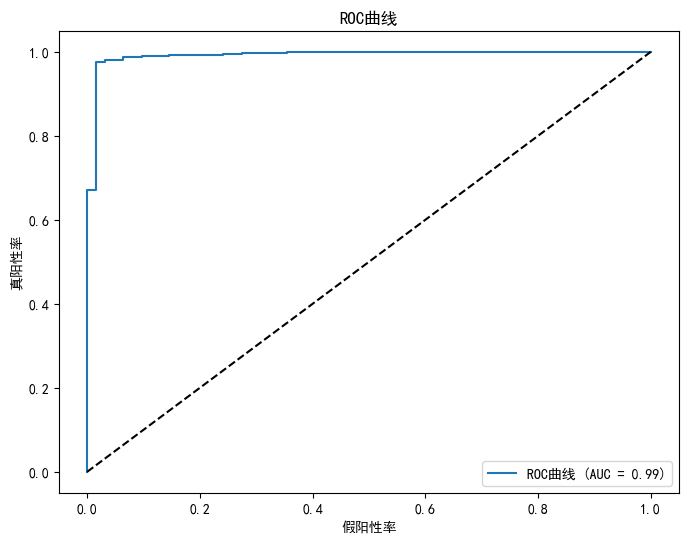

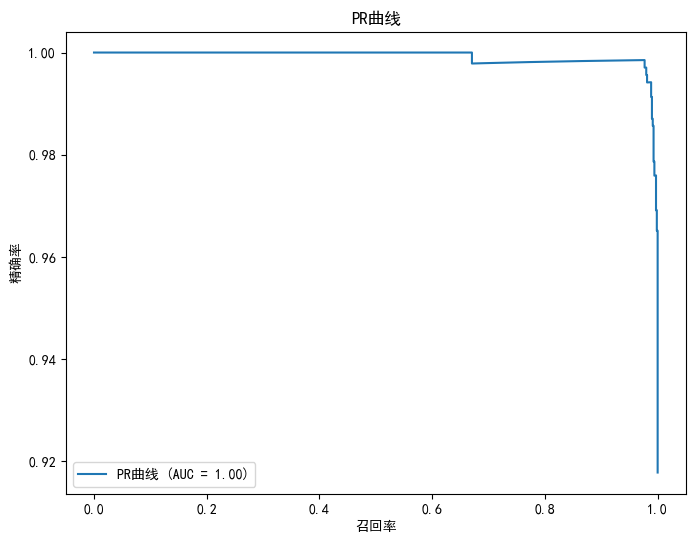


=== 网格搜索分析 ===
总共尝试了 243 种参数组合

表现最好的5种参数组合:
分数: 0.9932 (±0.0017)
参数: {'XGB__colsample_bytree': 0.8, 'XGB__learning_rate': 0.01, 'XGB__max_depth': 7, 'XGB__n_estimators': 300, 'XGB__subsample': 1.0}
---
分数: 0.9931 (±0.0015)
参数: {'XGB__colsample_bytree': 0.8, 'XGB__learning_rate': 0.01, 'XGB__max_depth': 7, 'XGB__n_estimators': 200, 'XGB__subsample': 1.0}
---
分数: 0.9931 (±0.0015)
参数: {'XGB__colsample_bytree': 0.8, 'XGB__learning_rate': 0.01, 'XGB__max_depth': 5, 'XGB__n_estimators': 300, 'XGB__subsample': 1.0}
---
分数: 0.9931 (±0.0016)
参数: {'XGB__colsample_bytree': 0.8, 'XGB__learning_rate': 0.01, 'XGB__max_depth': 5, 'XGB__n_estimators': 200, 'XGB__subsample': 1.0}
---
分数: 0.9930 (±0.0014)
参数: {'XGB__colsample_bytree': 0.9, 'XGB__learning_rate': 0.01, 'XGB__max_depth': 5, 'XGB__n_estimators': 200, 'XGB__subsample': 1.0}
---

特征重要性排序 (前10):
1. TSH: 0.6470
2. thyroxine: 0.0670
3. thyroidsurgery: 0.0428
4. TSHmeasured: 0.0406
5. FTI: 0.0195
6. T4: 0.0161
7. T3: 0.0155
8. FTImeasured: 0.01

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
import numpy as np

# 创建基础管道
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
pipe_xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("XGB", xgb_model)
])

# 设置网格搜索参数
param_grid = {
    'XGB__n_estimators': [100, 200, 300],           # 树的数量
    'XGB__max_depth': [3, 5, 7],                    # 树的最大深度
    'XGB__learning_rate': [0.01, 0.1, 0.2],         # 学习率
    'XGB__subsample': [0.8, 0.9, 1.0],              # 样本采样比例
    'XGB__colsample_bytree': [0.8, 0.9, 1.0]        # 特征采样比例
}

# 设置交叉验证策略
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 创建网格搜索对象
grid_search = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',          # 使用AUC作为评估指标
    n_jobs=-1,                  # 使用所有CPU核心
    verbose=1,                  # 显示进度
    return_train_score=True     # 返回训练分数
)

# 执行网格搜索
print("开始网格搜索...")
grid_search.fit(X_train, y_train)

print("\n网格搜索完成!")
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证分数: {grid_search.best_score_:.4f}")

# 使用最佳模型进行预测
best_pipe = grid_search.best_estimator_

# 评估最佳模型
print("\n最佳模型在测试集上的表现:")
print_model_scores(best_pipe, X_test, y_test)

# 绘制曲线
plot_roc_curve(y_test, best_pipe.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, best_pipe.predict_proba(X_test)[:, 1])

# 额外的分析信息
print("\n=== 网格搜索分析 ===")

# 查看所有参数组合的结果
results_df = pd.DataFrame(grid_search.cv_results_)
print(f"总共尝试了 {len(results_df)} 种参数组合")

# 查看前几名参数组合
top_results = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print("\n表现最好的5种参数组合:")
for i, row in top_results.iterrows():
    print(f"分数: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"参数: {row['params']}")
    print("---")

# 特征重要性分析（如果可用）
if hasattr(best_pipe.named_steps['XGB'], 'feature_importances_'):
    importances = best_pipe.named_steps['XGB'].feature_importances_
    feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(X_train.shape[1])]
    
    # 按重要性排序
    indices = np.argsort(importances)[::-1]
    print("\n特征重要性排序 (前10):")
    for i in range(min(10, len(importances))):
        print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

##### 处理数据集不平衡问题

In [33]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier
# from sklearn.metrics import recall_score, roc_auc_score

# # 计算正负样本比例
# negative_count = len(y[y == 1])
# positive_count = len(y[y == 0])
# scale_pos_weight = negative_count / positive_count

# print(f"负样本数: {negative_count}, 正样本数: {positive_count}")
# print(f"scale_pos_weight: {scale_pos_weight}")

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# xgb_model = XGBClassifier(
#     use_label_encoder=False, 
#     eval_metric="logloss",
#     scale_pos_weight=scale_pos_weight,  # 关键参数
#     random_state=42
# )

# pipe_xgb = Pipeline([
#     ("scaler", StandardScaler()),
#     ("XGB", xgb_model)
# ])

# pipe_xgb.fit(X_train, y_train)
# print("模型得分:", pipe_xgb.score(X_test, y_test))
# print("召回率:", recall_score(y_test, pipe_xgb.predict(X_test), pos_label=1))
# print("AUC评分:", roc_auc_score(y_test, pipe_xgb.predict_proba(X_test)[:, 1]))

#### LightGBM模型

开始网格搜索...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

最佳参数: {'LGBM__learning_rate': 0.05, 'LGBM__max_depth': 5, 'LGBM__num_leaves': 31}
最佳交叉验证召回率: 0.9828

测试集性能:
模型得分: 0.9787798408488063
召回率: 0.9884393063583815
AUC评分: 0.9853859779973895

最佳参数: {'LGBM__learning_rate': 0.05, 'LGBM__max_depth': 5, 'LGBM__num_leaves': 31}
最佳交叉验证召回率: 0.9828

测试集性能:
模型得分: 0.9787798408488063
召回率: 0.9884393063583815
AUC评分: 0.9853859779973895


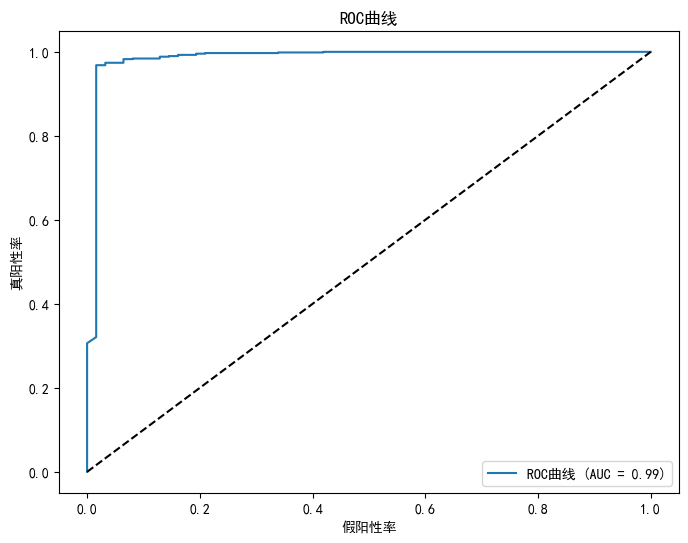

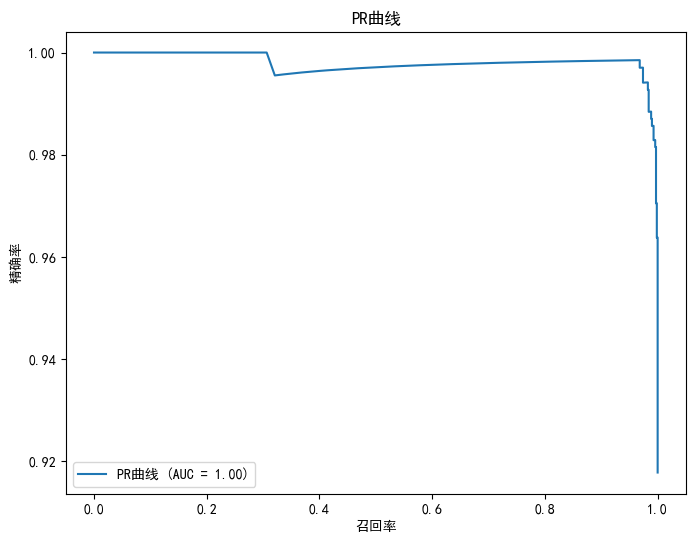

In [34]:
from sklearn.metrics import recall_score, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

# 定义自定义评估指标 - 召回率
recall_scorer = make_scorer(recall_score, pos_label=1)

# 初始化LightGBM分类器（简化版本）
lgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1,
    force_col_wise=True,
    objective='binary',
    boosting_type='gbdt',
    n_estimators=100  # 减少树的数量以加速
)

# 创建管道
pipe_lgbm = Pipeline([
    ("scaler", StandardScaler()),
    ("LGBM", lgbm_model)
])

# 简化参数网格
param_grid = {
    'LGBM__num_leaves': [31, 63],
    'LGBM__learning_rate': [0.05, 0.1],
    'LGBM__max_depth': [5, 7]
}

# 设置交叉验证策略
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 创建网格搜索对象
grid_search = GridSearchCV(
    estimator=pipe_lgbm,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# 执行网格搜索（不使用早停和其他复杂参数）
print("开始网格搜索...")
grid_search.fit(X_train, y_train)

# 输出结果
print(f"\n最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证召回率: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
print("\n测试集性能:")
print_model_scores(best_model, X_test, y_test)
plot_roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, best_model.predict_proba(X_test)[:, 1])

#### KNN

开始KNN随机搜索...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

最佳参数: {'KNN__algorithm': 'ball_tree', 'KNN__n_neighbors': 17, 'KNN__p': 2, 'KNN__weights': 'uniform'}
最佳交叉验证召回率: 0.9996

测试集性能:
模型得分: 0.9244031830238727
召回率: 0.9956647398843931

最佳参数: {'KNN__algorithm': 'ball_tree', 'KNN__n_neighbors': 17, 'KNN__p': 2, 'KNN__weights': 'uniform'}
最佳交叉验证召回率: 0.9996

测试集性能:
模型得分: 0.9244031830238727
召回率: 0.9956647398843931
AUC评分: 0.8013355398098079
AUC评分: 0.8013355398098079


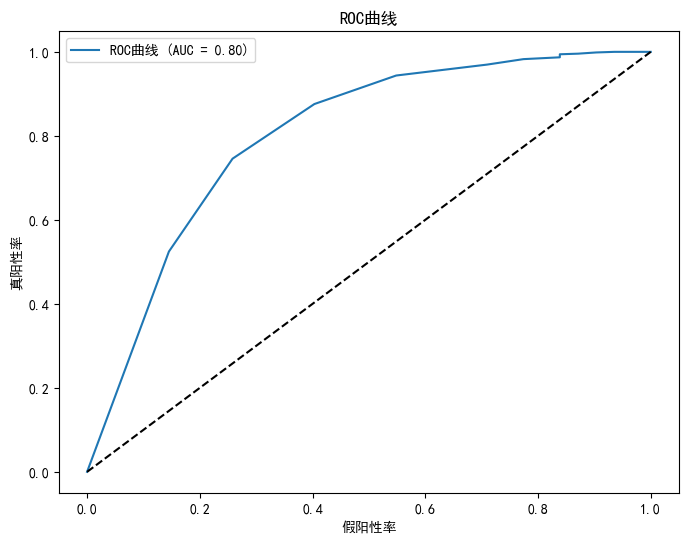

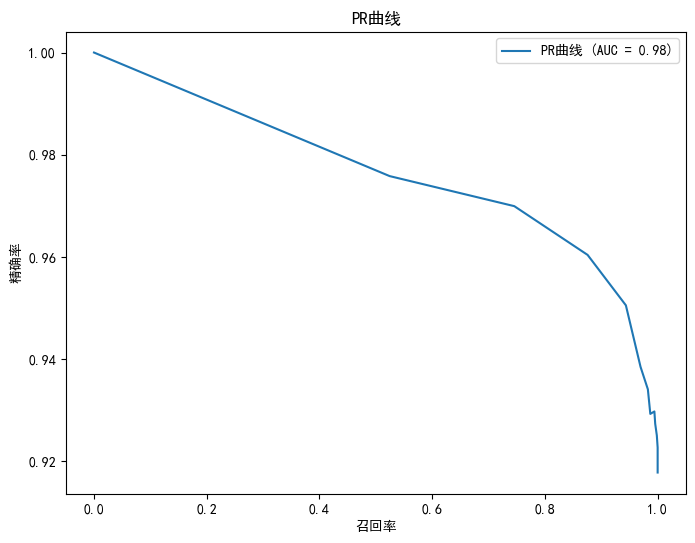

In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score
from scipy.stats import randint

# 首先定义KNN管道
knn_model = KNeighborsClassifier()
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("KNN", knn_model)
])

# 定义自定义评估指标 - 召回率
recall_scorer = make_scorer(recall_score, pos_label=1)

# 定义参数分布
param_dist = {
    'KNN__n_neighbors': randint(3, 20),          # 3到20之间的随机整数
    'KNN__weights': ['uniform', 'distance'],
    'KNN__p': [1, 2],
    'KNN__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# 创建随机搜索对象
random_search = RandomizedSearchCV(
    estimator=pipe_knn,
    param_distributions=param_dist,
    n_iter=20,  # 迭代次数
    scoring=recall_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),  # 减少折数
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

# 执行随机搜索
print("开始KNN随机搜索...")
random_search.fit(X_train, y_train)

# 输出结果
print(f"\n最佳参数: {random_search.best_params_}")
print(f"最佳交叉验证召回率: {random_search.best_score_:.4f}")

best_knn_model = random_search.best_estimator_
print("\n测试集性能:")
print_model_scores(best_knn_model, X_test, y_test)
plot_roc_curve(y_test, best_knn_model.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, best_knn_model.predict_proba(X_test)[:, 1])

#### SVM

开始SVM随机搜索...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

最佳参数: {'SVM__C': 0.1767016940294795, 'SVM__degree': 2, 'SVM__gamma': 0.0008263688714158015, 'SVM__kernel': 'linear'}
最佳交叉验证召回率: 1.0000

测试集性能:
模型得分: 0.9177718832891246
召回率: 1.0
AUC评分: 0.8157747529367891

最佳参数: {'SVM__C': 0.1767016940294795, 'SVM__degree': 2, 'SVM__gamma': 0.0008263688714158015, 'SVM__kernel': 'linear'}
最佳交叉验证召回率: 1.0000

测试集性能:
模型得分: 0.9177718832891246
召回率: 1.0
AUC评分: 0.8157747529367891


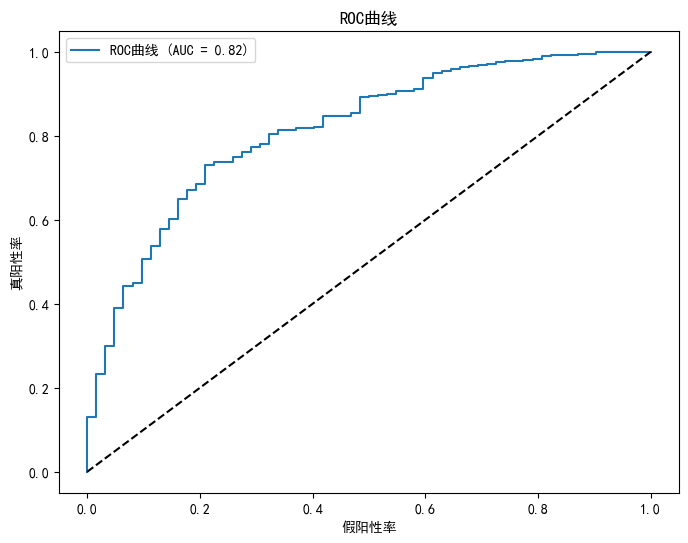

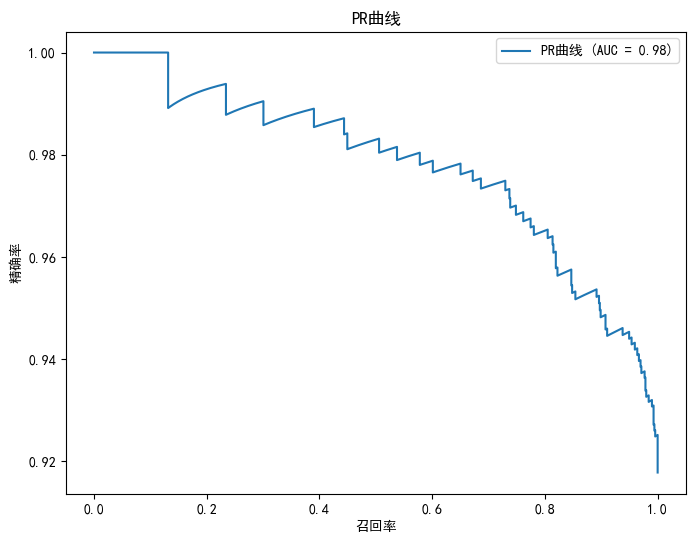

In [36]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, recall_score

# 定义召回率评分器
recall_scorer = make_scorer(recall_score)

# 首先定义SVM管道
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),  # SVM通常需要特征缩放
    ("SVM", SVC(probability=True, random_state=42))  # 注意这里的名称是"SVM"，要与参数分布中的前缀一致
])

# 定义参数分布
param_dist = {
    'SVM__C': loguniform(1e-3, 1e3),  # 对数均匀分布，覆盖更大范围
    'SVM__kernel': ['linear', 'rbf', 'poly'],
    'SVM__gamma': loguniform(1e-4, 1e1),
    'SVM__degree': [2, 3, 4]
}

# 创建随机搜索对象
random_search = RandomizedSearchCV(
    estimator=pipe_svm,  # 现在pipe_svm已经定义
    param_distributions=param_dist,
    n_iter=30,  # 迭代次数
    scoring=recall_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),  # 减少折数
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

# 执行随机搜索
print("开始SVM随机搜索...")
random_search.fit(X_train, y_train)

# 输出结果
print(f"\n最佳参数: {random_search.best_params_}")
print(f"最佳交叉验证召回率: {random_search.best_score_:.4f}")

best_svm_model = random_search.best_estimator_
print("\n测试集性能:")
print_model_scores(best_svm_model, X_test, y_test)
plot_roc_curve(y_test, best_svm_model.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, best_svm_model.predict_proba(X_test)[:, 1])

#### 随机森林

开始随机森林随机搜索...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

最佳参数: {'RF__bootstrap': False, 'RF__class_weight': None, 'RF__max_depth': 6, 'RF__max_features': 'sqrt', 'RF__min_samples_leaf': 5, 'RF__min_samples_split': 6, 'RF__n_estimators': 259}
最佳交叉验证召回率: 0.9982

测试集性能:
模型得分: 0.9283819628647215
召回率: 1.0
AUC评分: 0.9850829759462987

最佳参数: {'RF__bootstrap': False, 'RF__class_weight': None, 'RF__max_depth': 6, 'RF__max_features': 'sqrt', 'RF__min_samples_leaf': 5, 'RF__min_samples_split': 6, 'RF__n_estimators': 259}
最佳交叉验证召回率: 0.9982

测试集性能:
模型得分: 0.9283819628647215
召回率: 1.0
AUC评分: 0.9850829759462987


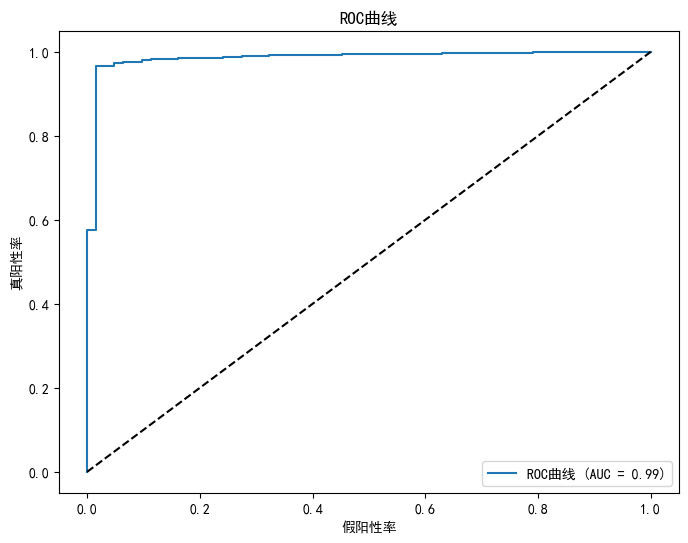

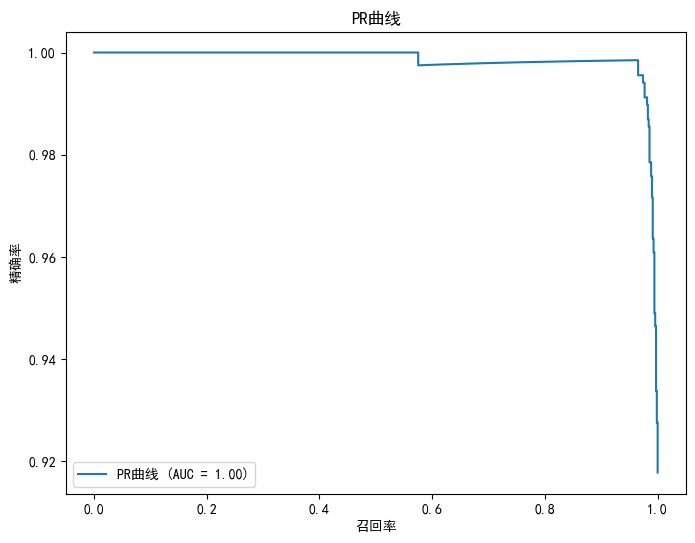

In [37]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler  # 随机森林对特征缩放不敏感，可根据需要选择
from sklearn.metrics import make_scorer, recall_score

# 定义召回率评分器（如果之前没定义的话）
recall_scorer = make_scorer(recall_score)

# 定义随机森林管道
pipe_rf = Pipeline([
    # 注意：随机森林通常不需要特征缩放，这里保留是为了保持与其他模型的一致性
    # 实际应用中可以移除StandardScaler
    ("scaler", StandardScaler()),  
    ("RF", RandomForestClassifier(random_state=42))  # 名称"RF"需与参数分布中的前缀一致
])

# 定义参数分布
param_dist = {
    'RF__n_estimators': randint(100, 500),           # 100-500之间的树
    'RF__max_depth': randint(5, 50),                 # 5-50的深度
    'RF__min_samples_split': randint(2, 20),         # 2-20的最小分割样本
    'RF__min_samples_leaf': randint(1, 10),          # 1-10的最小叶子样本
    'RF__max_features': ['sqrt', 'log2', None],      # 特征选择方式
    'RF__bootstrap': [True, False],
    'RF__class_weight': [None, 'balanced', 'balanced_subsample']
}

# 创建随机搜索对象
random_search = RandomizedSearchCV(
    estimator=pipe_rf,  # 现在pipe_rf已定义
    param_distributions=param_dist,
    n_iter=50,  # 迭代次数
    scoring=recall_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

# 执行随机搜索
print("开始随机森林随机搜索...")
random_search.fit(X_train, y_train)

# 输出结果
print(f"\n最佳参数: {random_search.best_params_}")
print(f"最佳交叉验证召回率: {random_search.best_score_:.4f}")

best_rf_model = random_search.best_estimator_
print("\n测试集性能:")
print_model_scores(best_rf_model, X_test, y_test)
plot_roc_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])

#### 逻辑回归

开始逻辑回归随机搜索...
训练数据形状: (3016, 33)
正样本比例: 0.924
Fitting 5 folds for each of 50 candidates, totalling 250 fits

搜索完成! 耗时: 14.29秒
最佳参数: {'LR__C': 0.0012329623163659848, 'LR__class_weight': None, 'LR__l1_ratio': 0.6174815096277165, 'LR__penalty': 'l2', 'LR__solver': 'newton-cg'}
最佳交叉验证召回率: 1.0000

最佳5个参数组合:
1. 召回率: 1.0000, 参数: {'LR__C': 0.0012329623163659848, 'LR__class_weight': None, 'LR__l1_ratio': 0.6174815096277165, 'LR__penalty': 'l2', 'LR__solver': 'newton-cg'}
2. 召回率: 1.0000, 参数: {'LR__C': 0.00011025488264291667, 'LR__class_weight': None, 'LR__l1_ratio': 0.2912291401980419, 'LR__penalty': 'l2', 'LR__solver': 'sag'}
3. 召回率: 1.0000, 参数: {'LR__C': 0.0059929552422241985, 'LR__class_weight': None, 'LR__l1_ratio': 0.07455064367977082, 'LR__penalty': 'l1', 'LR__solver': 'liblinear'}
4. 召回率: 1.0000, 参数: {'LR__C': 0.00028965395242758657, 'LR__class_weight': None, 'LR__l1_ratio': 0.6947849330397046, 'LR__penalty': 'l2', 'LR__solver': 'saga'}
5. 召回率: 1.0000, 参数: {'LR__C': 0.00010072151787441792

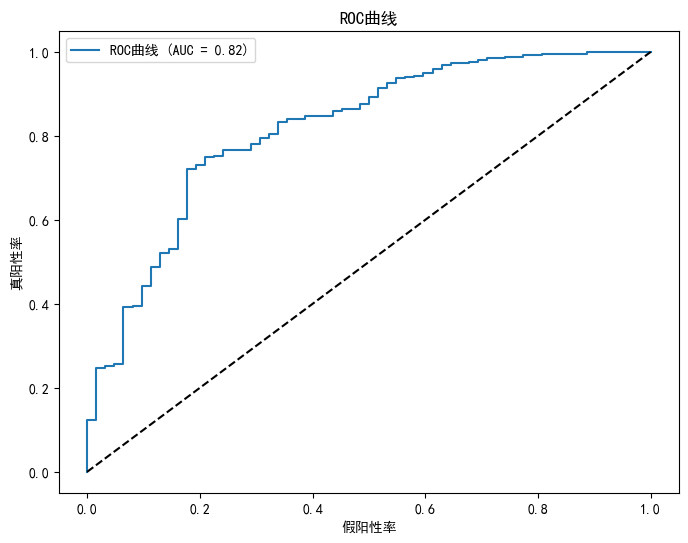

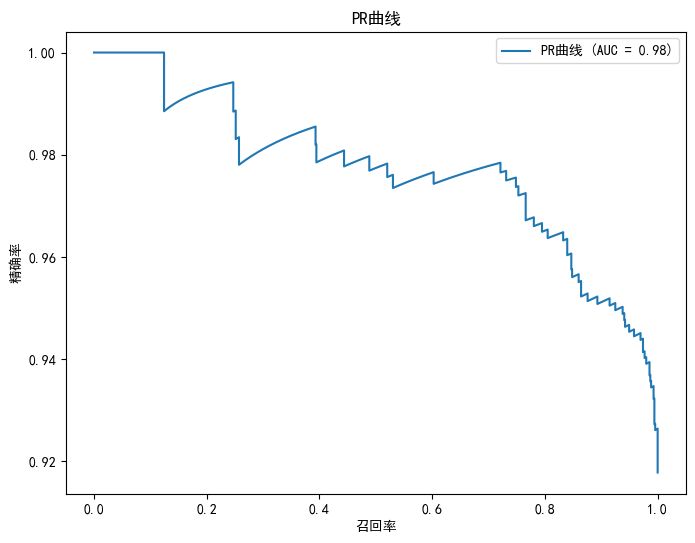


特征重要性 (前10个):
                 feature  importance
21                    T4    0.162801
25                   FTI    0.155842
19                    T3    0.077204
16           TSHmeasured    0.075100
2              thyroxine    0.052725
29  referral source_SVHC    0.046074
9       queryhypothyroid    0.043876
1                    sex    0.035673
23                   T4U    0.035294
20           TT4measured    0.031797


In [38]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, uniform
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, recall_score
import warnings
warnings.filterwarnings('ignore')

# 定义召回率评分器
recall_scorer = make_scorer(recall_score, average='binary', zero_division=0)

# 定义逻辑回归管道
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("LR", LogisticRegression(random_state=42, max_iter=2000, n_jobs=-1))
])

# 优化参数分布 - 考虑参数兼容性
param_dist = [
    # 对于liblinear和saga solver，支持l1和l2惩罚
    {
        'LR__solver': ['liblinear', 'saga'],
        'LR__penalty': ['l1', 'l2'],
        'LR__C': loguniform(1e-4, 1e2),
        'LR__class_weight': [None, 'balanced'],
        'LR__l1_ratio': uniform(0, 1)  # 仅对elasticnet有效，但这里不会冲突
    },
    # 对于lbfgs/newton-cg/sag solver，只支持l2惩罚
    {
        'LR__solver': ['lbfgs', 'newton-cg', 'sag'],
        'LR__penalty': ['l2'],
        'LR__C': loguniform(1e-4, 1e2),
        'LR__class_weight': [None, 'balanced'],
        'LR__l1_ratio': uniform(0, 1)
    },
    # 对于elasticnet惩罚，只支持saga solver
    {
        'LR__solver': ['saga'],
        'LR__penalty': ['elasticnet'],
        'LR__C': loguniform(1e-4, 1e2),
        'LR__class_weight': [None, 'balanced'],
        'LR__l1_ratio': uniform(0, 1)
    },
    # 无惩罚项的情况
    {
        'LR__penalty': [None],
        'LR__solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],
        'LR__class_weight': [None, 'balanced'],
        'LR__C': [1.0],  # 无惩罚时C参数无效，设为固定值
        'LR__l1_ratio': [0.5]  # 无效参数设为固定值
    }
]

# 创建随机搜索对象
random_search = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_dist,
    n_iter=50,  # 增加迭代次数以获得更好的结果
    scoring=recall_scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # 增加交叉验证折数
    n_jobs=-1,
    verbose=2,  # 更详细的输出
    random_state=42,
    refit=True,
    error_score='raise'  # 遇到错误时抛出异常以便调试
)

print("开始逻辑回归随机搜索...")
print(f"训练数据形状: {X_train.shape}")
print(f"正样本比例: {y_train.mean():.3f}")

# 添加计时功能
import time
start_time = time.time()

try:
    random_search.fit(X_train, y_train)
    end_time = time.time()
    
    print(f"\n搜索完成! 耗时: {end_time - start_time:.2f}秒")
    print(f"最佳参数: {random_search.best_params_}")
    print(f"最佳交叉验证召回率: {random_search.best_score_:.4f}")
    
    # 显示所有尝试的结果
    results_df = pd.DataFrame(random_search.cv_results_)
    print(f"\n最佳5个参数组合:")
    top_5 = results_df.nlargest(5, 'mean_test_score')
    for i, (_, row) in enumerate(top_5.iterrows()):
        print(f"{i+1}. 召回率: {row['mean_test_score']:.4f}, 参数: {row['params']}")
    
    best_random_model = random_search.best_estimator_
    
    print("\n测试集性能:")
    print_model_scores(best_random_model, X_test, y_test)
    
    # 绘制曲线
    plot_roc_curve(y_test, best_random_model.predict_proba(X_test)[:, 1])
    plot_pr_curve(y_test, best_random_model.predict_proba(X_test)[:, 1])
    
    # 特征重要性（对于线性模型）
    if hasattr(best_random_model.named_steps['LR'], 'coef_'):
        print("\n特征重要性 (前10个):")
        coef = best_random_model.named_steps['LR'].coef_[0]
        feature_importance = pd.DataFrame({
            'feature': X_train.columns if hasattr(X_train, 'columns') else range(len(coef)),
            'importance': abs(coef)
        })
        feature_importance = feature_importance.sort_values('importance', ascending=False)
        print(feature_importance.head(10))
        
except Exception as e:
    print(f"搜索过程中出现错误: {e}")
    print("建议检查参数兼容性或减少参数搜索空间")

#### GBDT

开始GBDT随机搜索...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

最佳参数组合: {'GBDT__learning_rate': 0.0745101528477201, 'GBDT__max_depth': 2, 'GBDT__max_features': 'sqrt', 'GBDT__min_samples_leaf': 6, 'GBDT__min_samples_split': 17, 'GBDT__n_estimators': 88, 'GBDT__subsample': 0.7880775532793479, 'GBDT__validation_fraction': 0.1}
最佳交叉验证召回率: 0.9957

测试集性能:
模型得分: 0.9496021220159151
召回率: 1.0
AUC评分: 0.9887423084094723

最佳参数组合: {'GBDT__learning_rate': 0.0745101528477201, 'GBDT__max_depth': 2, 'GBDT__max_features': 'sqrt', 'GBDT__min_samples_leaf': 6, 'GBDT__min_samples_split': 17, 'GBDT__n_estimators': 88, 'GBDT__subsample': 0.7880775532793479, 'GBDT__validation_fraction': 0.1}
最佳交叉验证召回率: 0.9957

测试集性能:
模型得分: 0.9496021220159151
召回率: 1.0
AUC评分: 0.9887423084094723


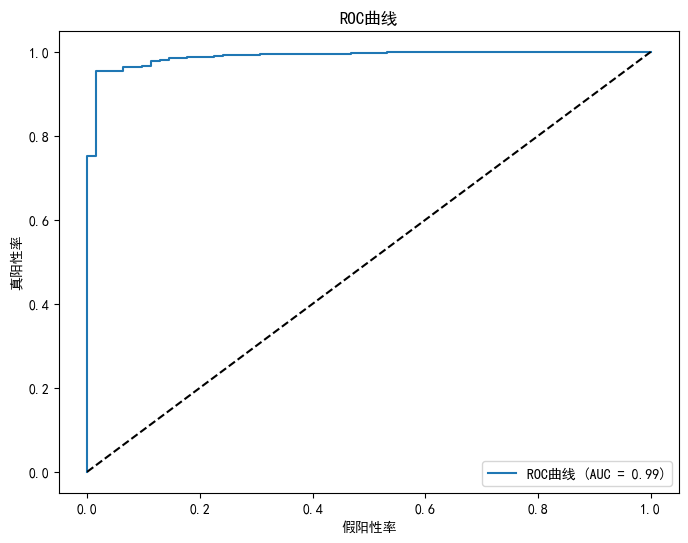

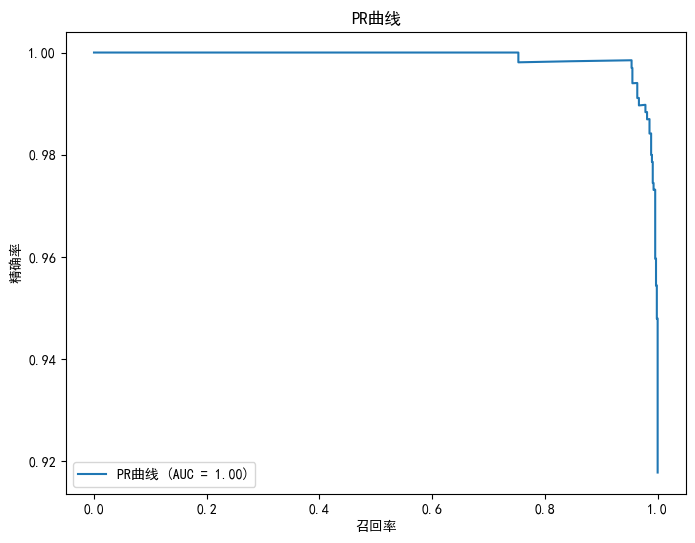

In [39]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, recall_score

# 定义召回率评分器
recall_scorer = make_scorer(
    recall_score,
    average='binary'
)

# 定义GBDT的Pipeline管道，修复参数错误
pipe_gbdt = Pipeline([
    ("scaler", StandardScaler()),
    ("GBDT", GradientBoostingClassifier(
        random_state=42,
        n_iter_no_change=10,  # 正确参数：连续10轮无改善则停止
        validation_fraction=0.1  # 用于早停的验证集比例
    ))
])

# 定义参数分布
param_dist = {
    'GBDT__n_estimators': randint(50, 500),
    'GBDT__learning_rate': uniform(0.01, 0.2),
    'GBDT__max_depth': randint(2, 8),
    'GBDT__min_samples_split': randint(2, 20),
    'GBDT__min_samples_leaf': randint(1, 10),
    'GBDT__subsample': uniform(0.7, 0.3),
    'GBDT__max_features': ['sqrt', 'log2', None],
    'GBDT__validation_fraction': [0.1, 0.2]
}

# 创建随机搜索对象
random_search = RandomizedSearchCV(
    estimator=pipe_gbdt,
    param_distributions=param_dist,
    n_iter=50,
    scoring=recall_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

print("开始GBDT随机搜索...")
random_search.fit(X_train, y_train)

print(f"\n最佳参数组合: {random_search.best_params_}")
print(f"最佳交叉验证召回率: {random_search.best_score_:.4f}")

best_random_model = random_search.best_estimator_
print("\n测试集性能:")
print_model_scores(best_random_model, X_test, y_test)
plot_roc_curve(y_test, best_random_model.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, best_random_model.predict_proba(X_test)[:, 1])

#### CatBoost

开始CatBoost随机搜索...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

最佳参数组合: {'CatBoost__bagging_temperature': 0.46994451399094295, 'CatBoost__border_count': 77, 'CatBoost__depth': 8, 'CatBoost__iterations': 105, 'CatBoost__l2_leaf_reg': 4.701587002554444, 'CatBoost__learning_rate': 0.01463698495866023, 'CatBoost__od_type': 'Iter', 'CatBoost__od_wait': 38, 'CatBoost__random_strength': 9.563682966346287}
最佳交叉验证召回率: 1.0000

测试集性能:
模型得分: 0.9230769230769231
召回率: 1.0
AUC评分: 0.9767853813164273

最佳参数组合: {'CatBoost__bagging_temperature': 0.46994451399094295, 'CatBoost__border_count': 77, 'CatBoost__depth': 8, 'CatBoost__iterations': 105, 'CatBoost__l2_leaf_reg': 4.701587002554444, 'CatBoost__learning_rate': 0.01463698495866023, 'CatBoost__od_type': 'Iter', 'CatBoost__od_wait': 38, 'CatBoost__random_strength': 9.563682966346287}
最佳交叉验证召回率: 1.0000

测试集性能:
模型得分: 0.9230769230769231
召回率: 1.0
AUC评分: 0.9767853813164273


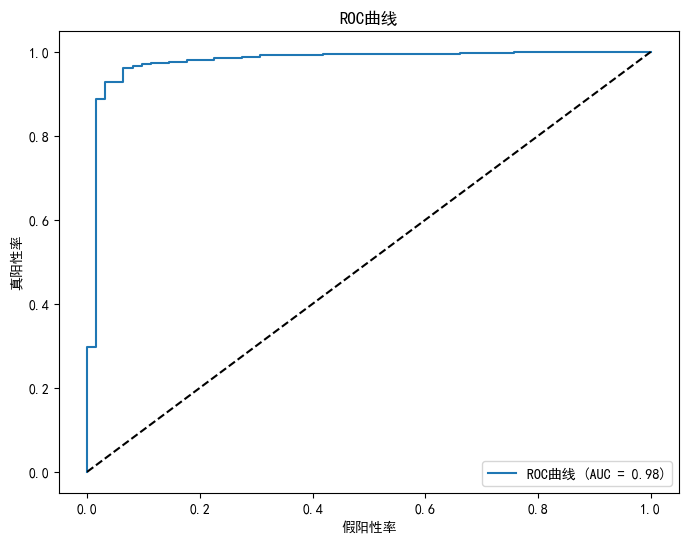

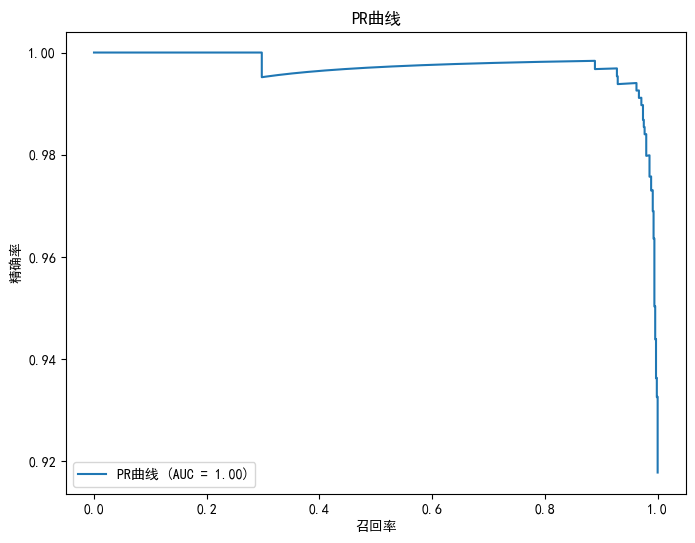

In [40]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, recall_score

# 定义召回率评分器
recall_scorer = make_scorer(
    recall_score,
    average='binary'
)

# 定义CatBoost的Pipeline管道
pipe_catboost = Pipeline([
    ("scaler", StandardScaler()),
    ("CatBoost", CatBoostClassifier(
        random_state=42,
        verbose=False,
        thread_count=-1  # 使用所有可用线程
    ))
])

# 定义参数分布
param_dist = {
    'CatBoost__iterations': randint(100, 500),
    'CatBoost__learning_rate': uniform(0.01, 0.3),
    'CatBoost__depth': randint(4, 10),
    'CatBoost__l2_leaf_reg': uniform(1, 10),
    'CatBoost__border_count': randint(32, 255),
    'CatBoost__bagging_temperature': uniform(0, 1),
    'CatBoost__random_strength': uniform(1, 20),
    'CatBoost__od_type': ['IncToDec', 'Iter'],
    'CatBoost__od_wait': randint(10, 50)
}

# 创建随机搜索对象
random_search = RandomizedSearchCV(
    estimator=pipe_catboost,
    param_distributions=param_dist,
    n_iter=50,
    scoring=recall_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

print("开始CatBoost随机搜索...")
random_search.fit(X_train, y_train)

print(f"\n最佳参数组合: {random_search.best_params_}")
print(f"最佳交叉验证召回率: {random_search.best_score_:.4f}")

best_catboost_model = random_search.best_estimator_
print("\n测试集性能:")
print_model_scores(best_catboost_model, X_test, y_test)
plot_roc_curve(y_test, best_catboost_model.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, best_catboost_model.predict_proba(X_test)[:, 1])

### 模型对比

In [41]:
def compare_all_models(X_test, y_test):
    """
    对比所有模型的性能
    使用图表展示对比结果
    """
    models = {
        'XGBoost': pipe_xgb,
        'LightGBM': pipe_lgbm,
        'KNN': pipe_knn,
        'SVM': pipe_svm,
        '随机森林': pipe_rf,
        '逻辑回归': pipe_lr,
        'GBDT': pipe_gbdt,
        'CatBoost': pipe_catboost
    }
    
    results = []
    
    for name, model in models.items():
        # 计算各项指标
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        accuracy = model.score(X_test, y_test)
        recall = recall_score(y_test, y_pred)
        auc_score = roc_auc_score(y_test, y_pred_proba)
        
        results.append({
            '模型': name,
            '准确率': accuracy,
            '召回率': recall,
            'AUC': auc_score
        })
    
    # 转换为DataFrame并按AUC排序
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('AUC', ascending=False)
    
    # 创建图表展示
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('模型性能对比', fontsize=16, fontweight='bold')
    
    # 1. 柱状图 - 所有指标
    ax1 = axes[0, 0]
    x = np.arange(len(results_df))
    width = 0.25
    
    ax1.bar(x - width, results_df['准确率'], width, label='准确率', alpha=0.8, color='skyblue')
    ax1.bar(x, results_df['召回率'], width, label='召回率', alpha=0.8, color='lightgreen')
    ax1.bar(x + width, results_df['AUC'], width, label='AUC', alpha=0.8, color='salmon')
    
    ax1.set_xlabel('模型')
    ax1.set_ylabel('得分')
    ax1.set_title('各模型性能指标对比')
    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df['模型'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.05)
    
    # 2. AUC排序柱状图
    ax2 = axes[0, 1]
    bars = ax2.barh(results_df['模型'], results_df['AUC'], color='coral', alpha=0.8)
    ax2.set_xlabel('AUC得分')
    ax2.set_title('AUC得分排序')
    ax2.grid(True, alpha=0.3)
    
    # 在柱状图上添加数值
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.4f}', ha='left', va='center', fontweight='bold')
    
    # 3. 雷达图
    ax3 = axes[1, 0]
    ax3.remove()  # 移除原有的子图
    ax3 = fig.add_subplot(2, 2, 3, projection='polar')
    
    # 选择前4个模型进行雷达图对比
    top4_models = results_df.head(4)
    categories = ['准确率', '召回率', 'AUC']
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # 闭合图形
    
    colors = ['red', 'blue', 'green', 'orange']
    for i, (idx, row) in enumerate(top4_models.iterrows()):
        values = [row['准确率'], row['召回率'], row['AUC']]
        values += values[:1]  # 闭合图形
        ax3.plot(angles, values, 'o-', linewidth=2, label=row['模型'], color=colors[i])
        ax3.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(categories)
    ax3.set_ylim(0, 1)
    ax3.set_title('Top 4 模型雷达图对比', pad=20)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax3.grid(True)
    
    # 4. 性能分布散点图
    ax4 = axes[1, 1]
    scatter = ax4.scatter(results_df['准确率'], results_df['召回率'], 
                         s=results_df['AUC']*500, alpha=0.7, c=results_df['AUC'], 
                         cmap='viridis', edgecolors='black')
    
    # 添加模型名称标注
    for i, row in results_df.iterrows():
        ax4.annotate(row['模型'], (row['准确率'], row['召回率']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    ax4.set_xlabel('准确率')
    ax4.set_ylabel('召回率')
    ax4.set_title('准确率 vs 召回率 (气泡大小=AUC)')
    ax4.grid(True, alpha=0.3)
    
    # 添加颜色条
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('AUC得分')
    
    plt.tight_layout()
    plt.show()
    
    # 输出简洁的表格总结
    print("=" * 60)
    print("                    模型性能总结")
    print("=" * 60)
    summary_df = results_df.copy()
    summary_df['准确率'] = summary_df['准确率'].apply(lambda x: f"{x:.4f}")
    summary_df['召回率'] = summary_df['召回率'].apply(lambda x: f"{x:.4f}")
    summary_df['AUC'] = summary_df['AUC'].apply(lambda x: f"{x:.4f}")
    print(summary_df.to_string(index=False))
    print("=" * 60)
    
    return results_df

# 执行对比
model_comparison = compare_all_models(X_test, y_test)

NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

### 超参优化

In [ ]:
# # 网格搜索&交叉验证
# from sklearn.model_selection import GridSearchCV

# params = {
#     'CatBoost__iterations': [100, 200, 300],
#     'CatBoost__learning_rate': [0.05, 0.1, 0.2],
#     'CatBoost__depth': [4, 6, 8],
#     'CatBoost__l2_leaf_reg': [1, 3, 5]
# }

# grid_search_cat = GridSearchCV(pipe_catboost, params, cv=5, scoring='roc_auc', verbose=1)
# grid_search_cat.fit(X_train, y_train)
# print_model_scores(grid_search_cat, X_test, y_test)

In [ ]:
# 更快更高效的超参优化方法
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, recall_score
from catboost import CatBoostClassifier
import optuna
import time
import warnings
warnings.filterwarnings("ignore")

# 设置optuna日志级别，减少输出
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Optuna目标函数：优化CatBoost关键参数
    只优化最重要的几个参数以提高效率
    """
    # 优化关键参数
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300),  # 减少范围以提高速度
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 5),
        'random_state': 42,
        'verbose': False
    }
    
    # 创建模型
    model = CatBoostClassifier(**params)
    
    # 创建Pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("catboost", model)
    ])
    
    # 使用3折交叉验证评估AUC（减少折数以提高速度）
    scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring='roc_auc')
    
    return scores.mean()

print("🚀 开始CatBoost超参数优化")
print("=" * 50)
print("📊 优化目标: 最大化AUC得分")
print("⚡ 优化算法: TPE (Tree-structured Parzen Estimator)")
print("🎯 试验次数: 20次 (高效模式)")
print("=" * 50)

# 创建study并设置优化方向
study = optuna.create_study(direction='maximize', 
                           sampler=optuna.samplers.TPESampler(seed=42))

# 记录开始时间
start_time = time.time()

# 执行优化（减少试验次数以控制时间）
study.optimize(objective, n_trials=20, show_progress_bar=True)

# 记录结束时间
end_time = time.time()

print(f"\n✅ 优化完成！耗时: {end_time - start_time:.1f}秒")
print("=" * 50)
print("🏆 最佳参数:")
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.4f}")
    else:
        print(f"   {key}: {value}")
print(f"\n🎯 最佳AUC得分: {study.best_value:.4f}")

# 使用最佳参数训练最终模型
print("\n" + "=" * 50)
print("🔧 使用最佳参数训练模型...")

best_catboost = CatBoostClassifier(**study.best_params)
best_pipe_catboost = Pipeline([
    ("scaler", StandardScaler()),
    ("catboost", best_catboost)
])

best_pipe_catboost.fit(X_train, y_train)

print("✅ 训练完成！")
print("\n" + "=" * 50)
print("📈 优化后模型在测试集上的表现:")

# 简化的评估函数
y_pred = best_pipe_catboost.predict(X_test)
y_pred_proba = best_pipe_catboost.predict_proba(X_test)[:, 1]
accuracy = best_pipe_catboost.score(X_test, y_test)
recall = recall_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"   准确率: {accuracy:.4f}")
print(f"   召回率: {recall:.4f}")
print(f"   AUC评分: {auc_score:.4f}")

# 对比优化前后的性能
print("\n" + "=" * 50)
print("📊 优化前后对比:")
original_auc = roc_auc_score(y_test, pipe_catboost.predict_proba(X_test)[:, 1])
print(f"   优化前AUC: {original_auc:.4f}")
print(f"   优化后AUC: {auc_score:.4f}")
improvement = auc_score - original_auc
if improvement > 0:
    print(f"   🎉 性能提升: +{improvement:.4f}")
else:
    print(f"   📝 性能变化: {improvement:.4f}")
print("=" * 50)

### 模型融合

In [ ]:
# 模型融合：使用表现最好的几个模型进行集成
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

print("🔥 开始模型融合")
print("=" * 50)

# 1. 选择表现最好的几个基础模型
base_models = [
    ('catboost', pipe_catboost),
    ('lightgbm', pipe_lgbm), 
    ('gbdt', pipe_gbdt),
    ('xgboost', pipe_xgb)
]

print("📊 基础模型:")
for name, model in base_models:
    print(f"   - {name}")

# 2. 软投票集成（使用预测概率）
print("\n🗳️  方法1: 软投票集成")
voting_clf = VotingClassifier(
    estimators=base_models,
    voting='soft'  # 使用预测概率进行投票
)

voting_clf.fit(X_train, y_train)
print("✅ 训练完成")

print("📈 软投票集成结果:")
print_model_scores(voting_clf, X_test, y_test)

# 3. 堆叠集成（使用逻辑回归作为元学习器）
print("\n" + "=" * 50)
print("🏗️  方法2: 堆叠集成")
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),  # 元学习器
    cv=3  # 3折交叉验证生成元特征
)

stacking_clf.fit(X_train, y_train)
print("✅ 训练完成")

print("📈 堆叠集成结果:")
print_model_scores(stacking_clf, X_test, y_test)

# 4. 性能对比
print("\n" + "=" * 50)
print("📊 融合效果对比")
print("=" * 50)

models_comparison = {
    'CatBoost(单模型)': pipe_catboost,
    'LightGBM(单模型)': pipe_lgbm,
    '软投票集成': voting_clf,
    '堆叠集成': stacking_clf
}

results = []
for name, model in models_comparison.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    accuracy = model.score(X_test, y_test)
    results.append({
        '模型': name,
        '准确率': f"{accuracy:.4f}",
        'AUC': f"{auc_score:.4f}"
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC', key=lambda x: x.astype(float), ascending=False)

print(results_df.to_string(index=False))

# 5. 找出最佳模型
best_model_name = results_df.iloc[0]['模型']
best_auc = results_df.iloc[0]['AUC']

print("\n" + "=" * 50)
print(f"🏆 最佳模型: {best_model_name}")
print(f"🎯 最佳AUC: {best_auc}")
print("=" * 50)